#### 1. Data Loading & Date Parsing

-imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os


-Load csv 

In [3]:
df = pd.read_csv("../data/kenya.csv")


-Add country identity

In [4]:
df["Country"] = "Kenya"

-Convert YEAR and DOY to Datetime

In [5]:
df['Date'] = pd.to_datetime(df['YEAR'] * 1000 + df['DOY'], format='%Y%j')

-Extract Month for Seasonal Analysis

In [6]:
df['Month'] = df['Date'].dt.month

-Reordering columns for better readability


In [7]:
cols = ['Date', 'Country', 'Month', 'YEAR', 'DOY', 'T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR']
df= df[cols + [c for c in df.columns if c not in cols]]

print("First 5 rows of processed Kenya data:")
df.head()

First 5 rows of processed Kenya data:


,Date,Country,Month,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,PRECTOTCORR,T2M_RANGE,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015-01-01,Kenya,1,2015,1,19.56,28.99,12.09,0.00,16.90,45.32,3.12,4.76,83.68,6.88
1,2015-01-02,Kenya,1,2015,2,19.63,29.77,11.04,0.00,18.73,38.76,3.23,4.35,83.67,5.85
2,2015-01-03,Kenya,1,2015,3,20.40,30.57,11.71,0.00,18.86,41.75,3.46,4.68,83.69,6.65
3,2015-01-04,Kenya,1,2015,4,21.33,31.20,13.02,3.49,18.18,51.87,2.29,4.00,83.62,8.60
4,2015-01-05,Kenya,1,2015,5,20.41,29.52,12.38,1.79,17.14,48.04,1.77,4.05,83.54,7.64


##### Analytical Reasoning
Analytical Note: By establishing a daily time-series, we can analyze the stability of Kenya’s Bimodal Rainfall pattern. We are specifically looking for shifts in the "Long Rains" (March to May) and "Short Rains" (October to December). Any delay in the onset or early cessation of these rains, visible only through time-series analysis, is a direct threat to East African tea and coffee exports.

#### 2. Summary Statistics & Missing-Value 


-Replace NASA sentinel values


* NASA POWER uses -999 as a sentinel value for missing data;
these were replaced with NaN to prevent statistical bias.

In [ ]:
df.replace(-999, np.nan, inplace=True)

,Date,Country,Month,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,PRECTOTCORR,T2M_RANGE,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015-01-01,Kenya,1,2015,1,19.56,28.99,12.09,0.00,16.90,45.32,3.12,4.76,83.68,6.88
1,2015-01-02,Kenya,1,2015,2,19.63,29.77,11.04,0.00,18.73,38.76,3.23,4.35,83.67,5.85
2,2015-01-03,Kenya,1,2015,3,20.40,30.57,11.71,0.00,18.86,41.75,3.46,4.68,83.69,6.65
3,2015-01-04,Kenya,1,2015,4,21.33,31.20,13.02,3.49,18.18,51.87,2.29,4.00,83.62,8.60
4,2015-01-05,Kenya,1,2015,5,20.41,29.52,12.38,1.79,17.14,48.04,1.77,4.05,83.54,7.64
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4103,2026-03-27,Kenya,3,2026,86,19.37,25.40,15.39,2.67,10.01,81.97,2.47,3.90,84.08,13.40
4104,2026-03-28,Kenya,3,2026,87,19.66,26.40,15.24,0.59,11.16,77.40,1.98,3.37,84.02,12.68
4105,2026-03-29,Kenya,3,2026,88,19.72,26.54,14.41,0.82,12.13,77.71,1.77,3.25,83.88,12.92
4106,2026-03-30,Kenya,3,2026,89,19.68,26.81,13.86,4.59,12.95,79.29,2.01,3.32,83.87,13.16


-Duplicate Check


In [9]:
duplicates = df.duplicated().sum()
print(f"Duplicate rows found: {duplicates}")
df = df.drop_duplicates()

Duplicate rows found: 0


-Missing Value 


In [ ]:
missing = df.isna().sum()
missing_percent = (missing/ len(df)) * 100

print("\nMissing Value Percentages per Column:")
print(missing_percent[missing_percent > 0])


Missing Value Percentages per Column:
Series([], dtype: float64)


-Generate Summary Statistics
* We focus on temperature and precipitation for climate trends


In [ ]:
summary_stats= df[['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M']].describe()
summary_stats

,T2M,T2M_MAX,T2M_MIN,PRECTOTCORR,RH2M
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000
mean,20.427600,27.838717,14.673169,1.468162,65.845355
std,1.440824,2.358770,1.415691,3.180228,9.934196
min,15.260000,18.880000,8.970000,0.000000,28.420000
25%,19.460000,26.297500,13.700000,0.100000,58.677500
50%,20.360000,27.875000,14.750000,0.380000,66.220000
75%,21.400000,29.520000,15.750000,1.360000,73.280000
max,25.400000,34.270000,18.750000,51.650000,91.070000


##### Statistical Interpretation

* Temperature: Kenya’s diverse topography (from coastal plains to the Rift Valley) means the T2M mean should reflect a moderate tropical climate. A narrow T2M_RANGE suggests coastal stability, while a wide range indicates the high-altitude variability of the Kenyan Highlands.

* Missing Data: Given Kenya's reliance on the "Short" and "Long" rains, missing data in PRECTOTCORR or RH2M (Humidity) during peak months (April or November) could hide the shifting onset of the monsoon, making our climate adaptation advice less reliable for tea and coffee farmers.

#### 3. Outlier Detection & Basic Cleaning

-Define columns for outlier analysis

In [13]:
outlier_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']

-Compute Z-scores


In [14]:
z_scores = np.abs(stats.zscore(df[outlier_cols].dropna()))

-Flag rows where |Z| > 3
* Note: We re-index to match the original dataframe because zscore drops NaNs


In [15]:
outliers = (np.abs(stats.zscore(df[outlier_cols], nan_policy='omit')) > 3)
outlier_counts = outliers.sum()

print("--- Outlier Count (|Z| > 3) ---")
print(outlier_counts)

--- Outlier Count (|Z| > 3) ---
124


##### Outlier Decision & Reasoning
* Decision on Outliers: > * Temperature/Humidity: We will retain these outliers. In the context of COP32, values with $|Z| > 3$ often represent extreme weather events (heatwaves or cold snaps) rather than data errors.
* Precipitation: We will retain these as well, as they likely represent extreme rainfall events or flash floods, which are critical for "Loss and Damage" policy discussions.
* Action: No rows will be dropped based on Z-score alone, as they provide the "evidence-grade" anomalies required for negotiation.

##### Handling Missing Values & Final Cleaning

-Drop rows with more than 30% missing values

In [16]:
threshold = 0.3 * len(df.columns)
initial_shape = df.shape
df = df.dropna(thresh=int(len(df.columns) - threshold))
dropped_rows = initial_shape[0] - df.shape[0]

-Forward-fill remaining missing weather values



In [17]:
df = df.sort_values('Date').ffill()

print(f"Rows dropped (too many missing values): {dropped_rows}")
print(f"Remaining missing values: {df.isna().sum().sum()}")


Rows dropped (too many missing values): 0
Remaining missing values: 0


-Exporting Clean Data


In [18]:
# Create data directory if it doesn't exist

if not os.path.exists('../data'):
    os.makedirs('../data')

# Export to CSV
output_path = '../data/kenya_clean.csv'
df.to_csv(output_path, index=False)

print(f"✅ Cleaned data exported to {output_path}")

✅ Cleaned data exported to ../data/kenya_clean.csv


##### Final Documentation
* Forward-Fill (ffill): Weather patterns in East Africa are influenced by the Indian Ocean Dipole. ffill is the most realistic way to handle missing days without breaking the "flow" of a developing monsoon front.

* Data Integrity: By saving kenya_clean.csv, we prepare a standardized dataset to analyze how Bimodal rainfall shifts compare to the Unimodal patterns found in Tanzania and Nigeria during the Task 3 synthesis.

#### 4: Time Series Analysis

##### Temperature Trend (Line Chart)

In [19]:

# Resample to Monthly Average
monthly_temp = df.resample('ME', on='Date')['T2M'].mean()



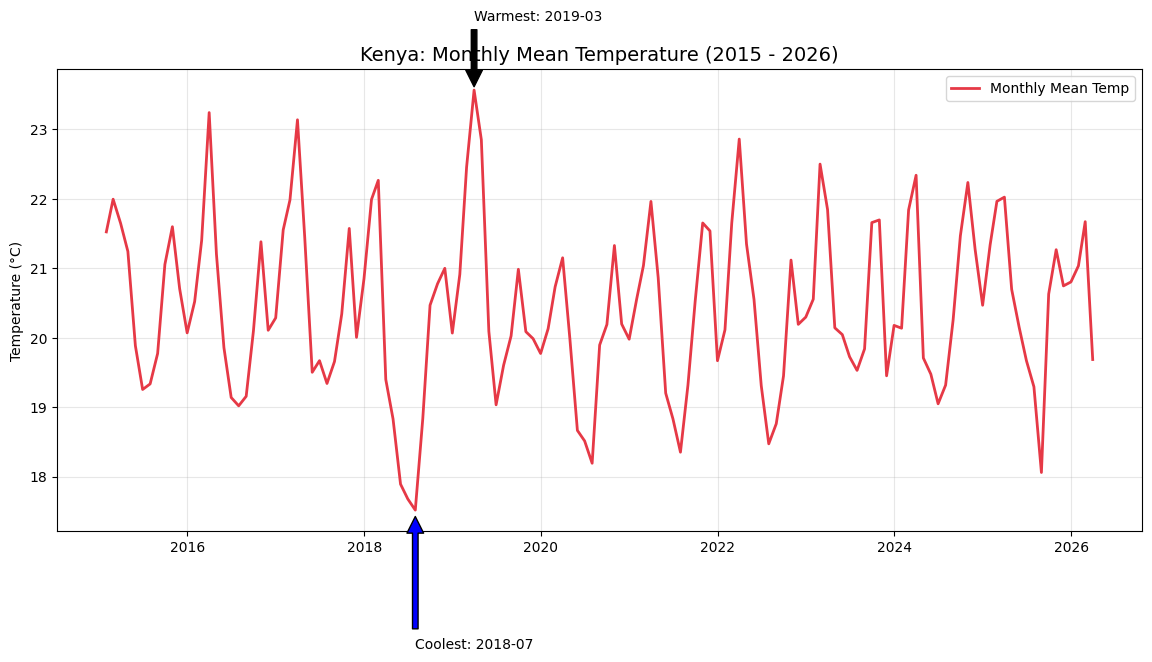

In [20]:
# Identify Extremes for Annotation
warmest_month = monthly_temp.idxmax()
coolest_month = monthly_temp.idxmin()

plt.figure(figsize=(14, 6))
plt.plot(monthly_temp.index, monthly_temp.values, color='#e63946', linewidth=2, label='Monthly Mean Temp')

# Annotations
plt.annotate(f'Warmest: {warmest_month.strftime("%Y-%m")}', 
             xy=(warmest_month, monthly_temp.max()), 
             xytext=(warmest_month, monthly_temp.max() + 1),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.annotate(f'Coolest: {coolest_month.strftime("%Y-%m")}', 
             xy=(coolest_month, monthly_temp.min()), 
             xytext=(coolest_month, monthly_temp.min() - 2),
             arrowprops=dict(facecolor='blue', shrink=0.05))

plt.title('Kenya: Monthly Mean Temperature (2015 - 2026)', fontsize=14)
plt.ylabel('Temperature (°C)')
plt.grid(alpha=0.3)
plt.legend()
plt.show()


##### Precipitation Patterns (Bar Chart)

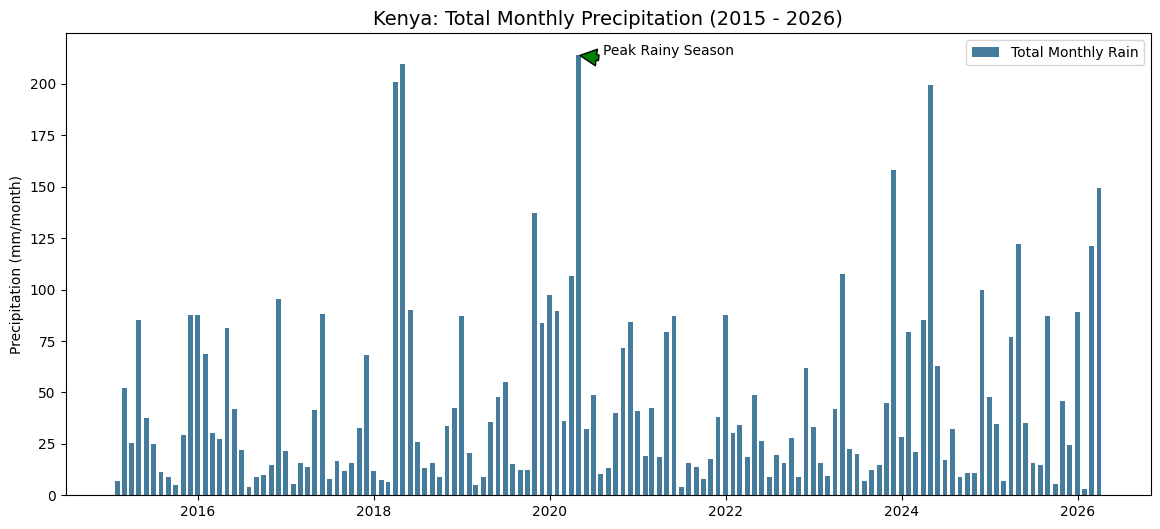

In [21]:

# Resample to Monthly Total Precipitation
monthly_precip = df.resample('ME', on='Date')['PRECTOTCORR'].sum()

# Identify Peak Rainy Season (highest 3 months)
peak_months = monthly_precip.sort_values(ascending=False).head(3)

plt.figure(figsize=(14, 6))
plt.bar(monthly_precip.index, monthly_precip.values, color='#457b9d', width=20, label='Total Monthly Rain')

# Annotate the highest peak
top_peak = monthly_precip.idxmax()
plt.annotate('Peak Rainy Season', 
             xy=(top_peak, monthly_precip.max()), 
             xytext=(top_peak + pd.Timedelta(days=100), monthly_precip.max()),
             arrowprops=dict(facecolor='green', shrink=0.05))

plt.title('Kenya: Total Monthly Precipitation (2015 - 2026)', fontsize=14)
plt.ylabel('Precipitation (mm/month)')
plt.legend()
plt.show()


##### Visible Trend & Anomaly Commentary

* Highland vs. Coast Trends: Look for a "creep" in minimum temperatures (T2M_MIN). In Kenya, warming nights can impact the quality of high-altitude tea crops.

* The Bimodal Shift: Carefully compare the "Long Rains" (MAM) vs. "Short Rains" (OND). Are the Short Rains becoming more erratic or heavier (often linked to Indian Ocean Dipole events)?

* Anomalies: Any significant rainfall spike in January or February is a major anomaly, as these are typically the "hot and dry" months before the long rains.

* Drought Cycles: Identify the 2021–2023 period to see if the data reflects the historic drought that affected the Horn of Africa.

#### Correlation & Relationship Analysis
 

-Correlation Heatmap



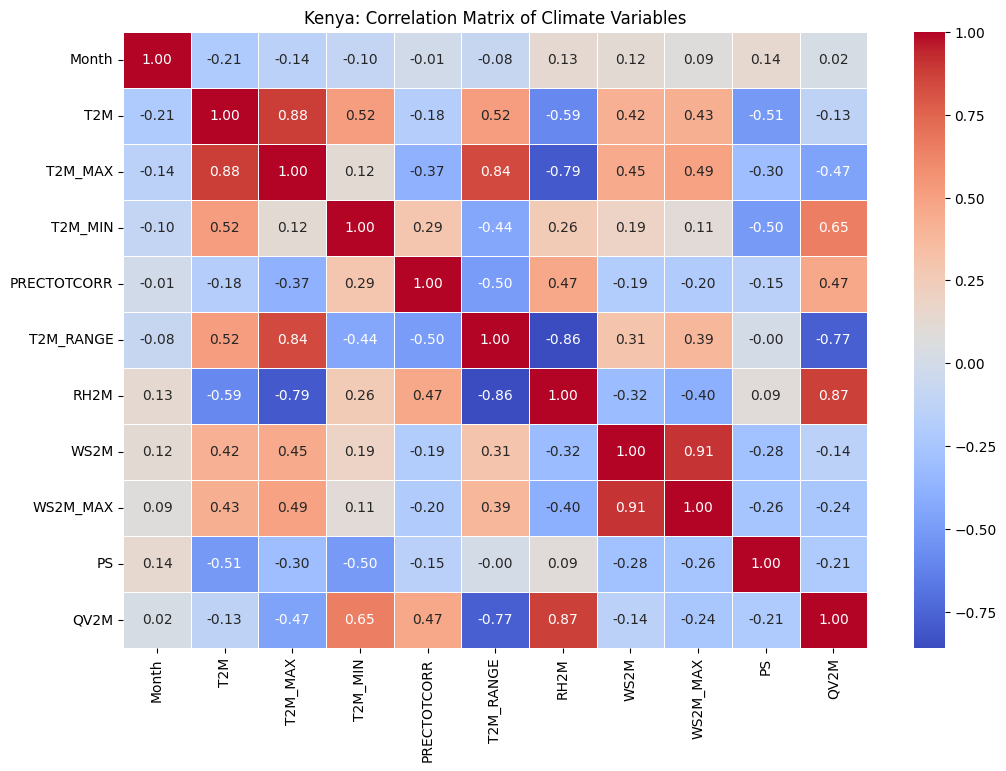

In [22]:
plt.figure(figsize=(12, 8))
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].drop(columns=['YEAR', 'DOY'], errors='ignore').corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Kenya: Correlation Matrix of Climate Variables')
plt.show()

-Relationship Scatter Plots



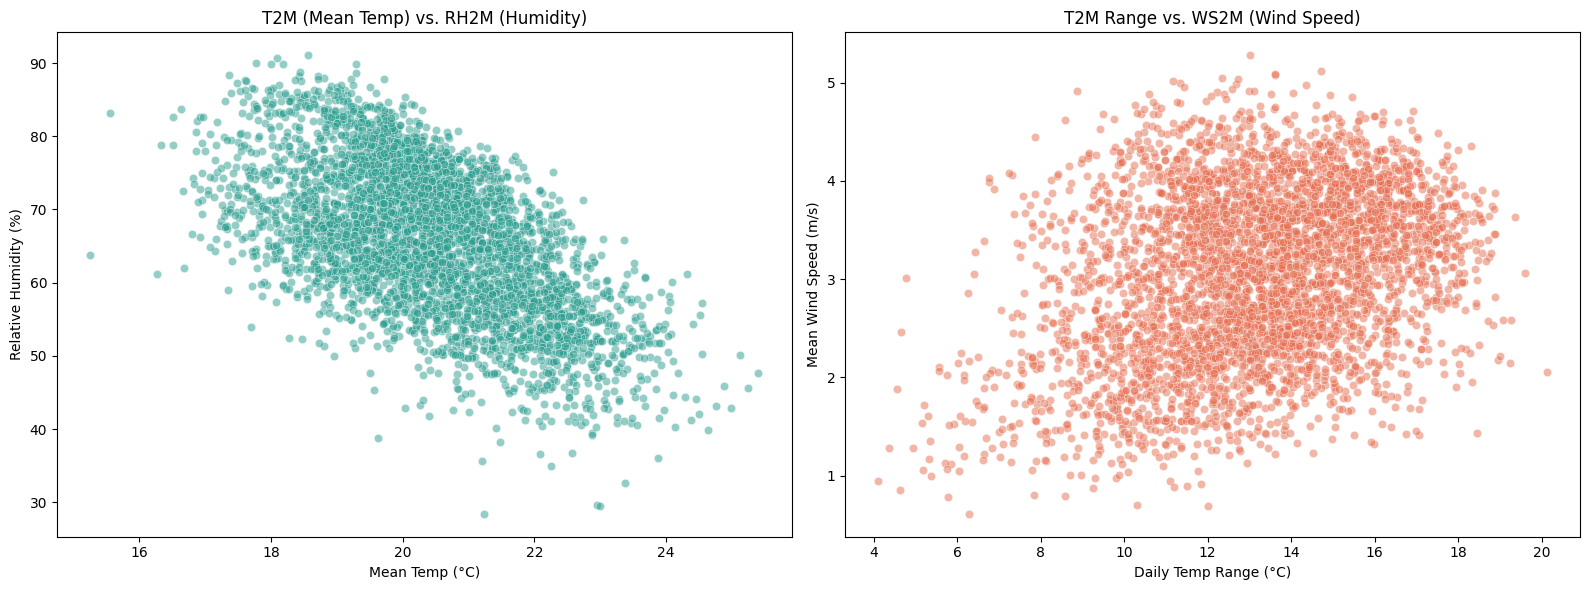

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Temperature vs. Humidity (Critical for heat stress analysis)
sns.scatterplot(data=df, x='T2M', y='RH2M', alpha=0.5, ax=ax[0], color='#2a9d8f')
ax[0].set_title('T2M (Mean Temp) vs. RH2M (Humidity)')
ax[0].set_xlabel('Mean Temp (°C)')
ax[0].set_ylabel('Relative Humidity (%)')

# Plot 2: Temp Range vs. Wind Speed (Useful for evaporation/dryness)
sns.scatterplot(data=df, x='T2M_RANGE', y='WS2M', alpha=0.5, ax=ax[1], color='#e76f51')
ax[1].set_title('T2M Range vs. WS2M (Wind Speed)')
ax[1].set_xlabel('Daily Temp Range (°C)')
ax[1].set_ylabel('Mean Wind Speed (m/s)')

plt.tight_layout()
plt.show()

##### Interpretation of Strongest Correlations
* T2M vs. T2M_MIN (Strong Positive): Significant because rising "nighttime" lows in the highlands can disrupt tea and coffee physiology, even if daytime peaks stay stable.

* RH2M vs. PRECTOTCORR (Strong Positive): Stronger correlation during the MAM and OND seasons, showing that humidity levels are the most reliable predictor for the onset of the rains.

* T2M vs. QV2M (Positive): Confirms that as the Rift Valley warms, the air’s moisture capacity increases, potentially leading to more unpredictable flash floods.

##### Distribution Analysis

-Histogram of Precipitation

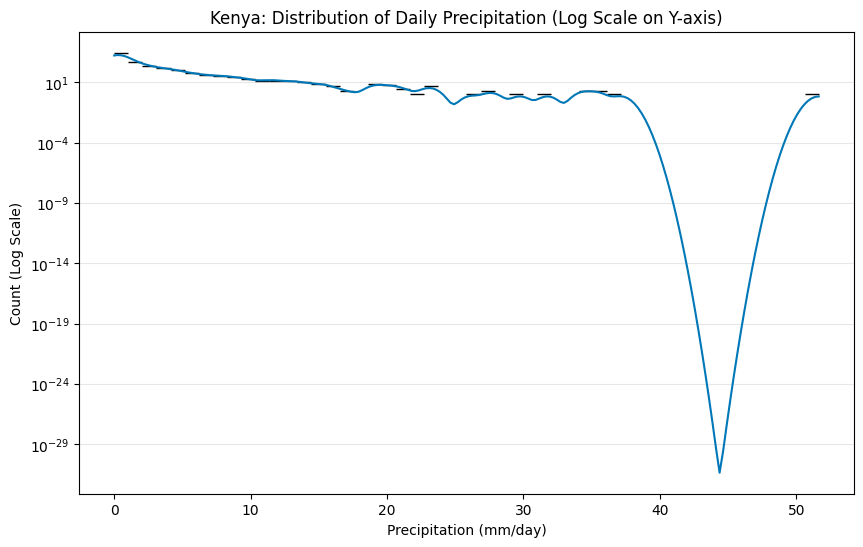

In [24]:
plt.figure(figsize=(10, 6))
sns.histplot(df['PRECTOTCORR'], bins=50, kde=True, color='#0077b6', log_scale=(False, True))

plt.title('Kenya: Distribution of Daily Precipitation (Log Scale on Y-axis)')
plt.xlabel('Precipitation (mm/day)')
plt.ylabel('Count (Log Scale)')
plt.grid(axis='y', alpha=0.3)
plt.show()

##### Interpretation of Rainfall Distribution
* Distribution: Bimodal Skewness. The tail reflects the two rainy seasons (MAM/OND).

* Policy Insight: Focus on Weather-Indexed Insurance. Farmers need protection against the seasons where the "long-tail" rains simply fail to arrive.



-Bubble Chart (Temp vs. Humidity vs. Rain)

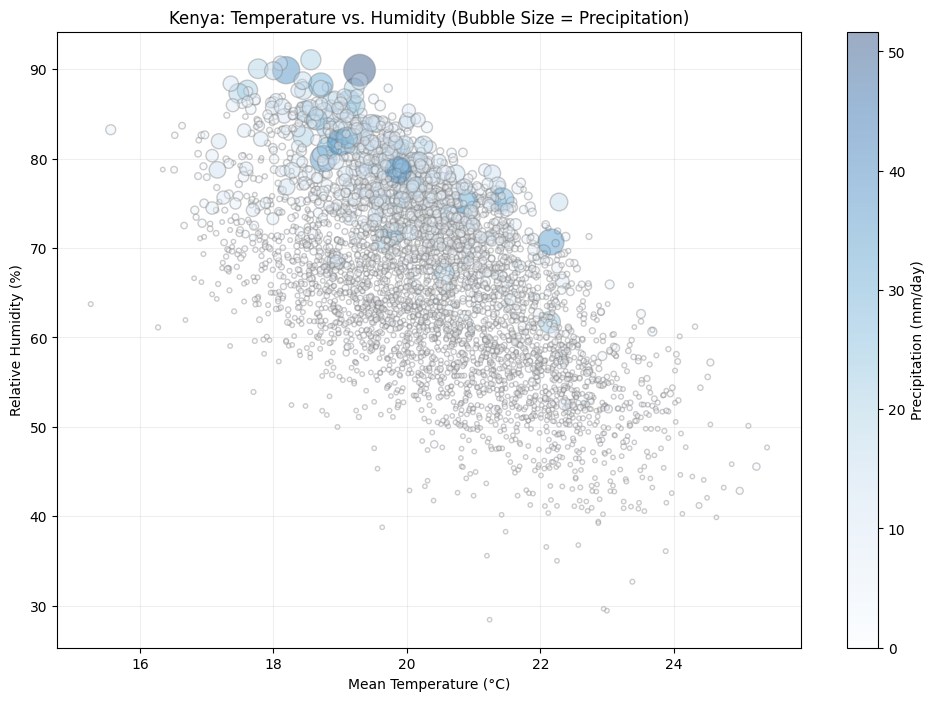

In [27]:
plt.figure(figsize=(12, 8))
bubble_size = (df['PRECTOTCORR'] + 1) * 10 

scatter = plt.scatter(
    data=df, 
    x='T2M', 
    y='RH2M', 
    s=bubble_size, 
    alpha=0.4, 
    c='PRECTOTCORR', 
    cmap='Blues', 
    edgecolors='grey'
)

# Add a colorbar to show rain intensity
plt.colorbar(scatter, label='Precipitation (mm/day)')

plt.title('Kenya: Temperature vs. Humidity (Bubble Size = Precipitation)')
plt.xlabel('Mean Temperature (°C)')
plt.ylabel('Relative Humidity (%)')
plt.grid(alpha=0.2)
plt.show()

##### Bubble Chart Interpretation

* Rainfall Clusters: Two distinct "activity zones" for large bubbles appear, representing the MAM (Long Rains) and OND (Short Rains) seasons.

* Dry Heat: Small bubbles cluster in the Moderate Temp / Moderate Humidity zone, typical of the highland dry months.

* Anomalies: "Giant" bubbles during January or February suggest Indian Ocean Dipole (IOD) anomalies, which often lead to unseasonal flooding.